<a href="https://colab.research.google.com/github/Adittopiwala2/Adit-/blob/master/CiFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
#loading data set
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
x_train = train_images/255.0
x_test = test_images/255.0
y_train = train_labels
y_test = test_labels

class_name = ['airplane', 'automobile', 'bird', 'cat', 'dear', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape: ",x_train.shape)
print("Training labels shape: ",y_train.shape)
print("Testing data shape: ",x_test.shape)
print("Testing labels shape: ",y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Testing data shape:  (10000, 32, 32, 3)
Testing labels shape:  (10000, 1)


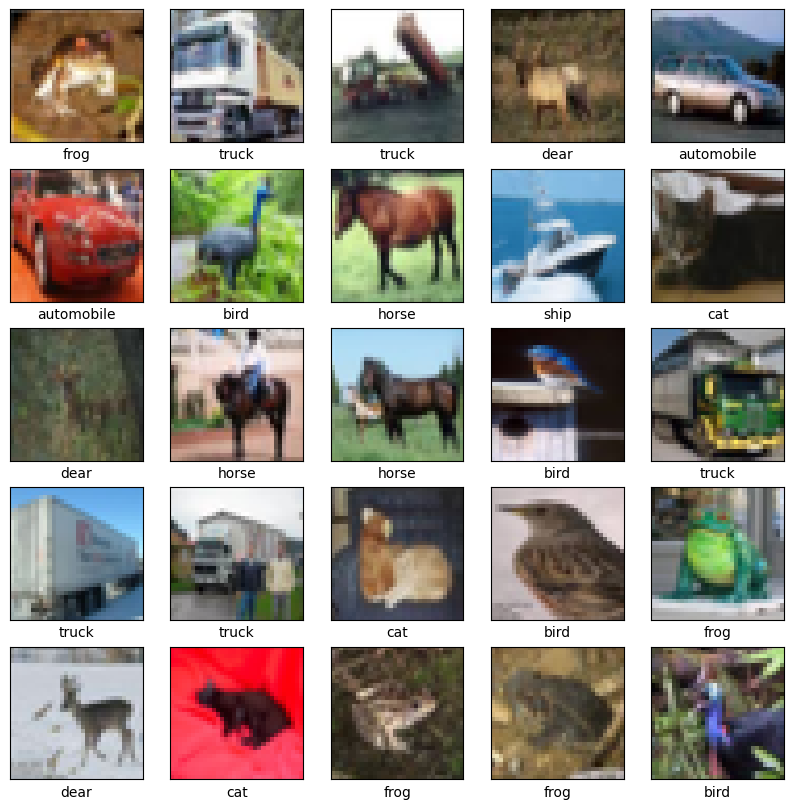

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_name[y_train[i][0]])
plt.show()

In [15]:
model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Dropout(0.25), # Added dropout after the last convolutional block
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25), # Added dropout after the first dense layer
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,426 (1.39 MB)

 Trainable params: 364,426 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [18]:
history = model.fit(x_train, y_train, epochs=8, batch_size = 64,
                    validation_split = 0.20, verbose = 1)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 101ms/step - accuracy: 0.3855 - loss: 1.6578 - val_accuracy: 0.4957 - val_loss: 1.3788
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 96ms/step - accuracy: 0.5257 - loss: 1.3211 - val_accuracy: 0.5707 - val_loss: 1.1973
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.5851 - loss: 1.1683 - val_accuracy: 0.6111 - val_loss: 1.0936
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6237 - loss: 1.0640 - val_accuracy: 0.6383 - val_loss: 1.0266
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.6527 - loss: 0.9811 - val_accuracy: 0.6614 - val_loss: 0.9565
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.6794 - loss: 0.9041 - val_accuracy: 0.6848 - val_loss: 0.9013
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7006 - loss: 0.8492 - val_accuracy: 0.6763 - val_loss: 0.9449
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7196 - loss: 0.7936 - val_acc

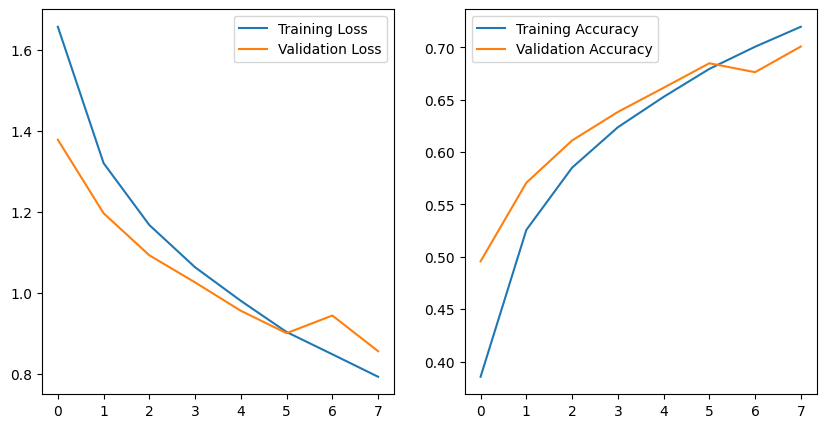

In [19]:
plt.figure(num=12, figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy: ", test_accuracy)
print("Test loss: ", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6982 - loss: 0.8753
Test accuracy:  0.698199987411499
Test loss:  0.8752874135971069


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


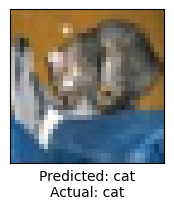

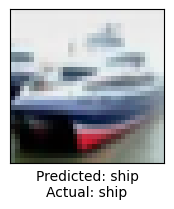

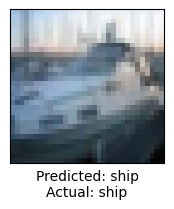

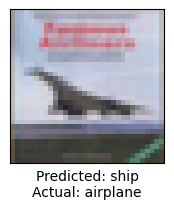

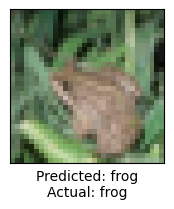

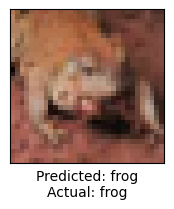

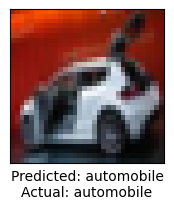

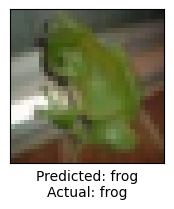

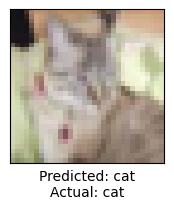

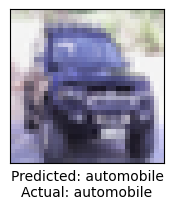

In [24]:
predictions = model.predict(x_test)
for i in range(10):
  predicted_classes = np.argmax(predictions, axis=1)
  Actual_classes = y_test[i][0]
  plt.figure(figsize=(2,2))
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_test[i])
  plt.xlabel(f"Predicted: {class_name[predicted_classes[i]]}\nActual: {class_name[Actual_classes]}")
plt.show()

<Figure size 1000x1000 with 0 Axes>

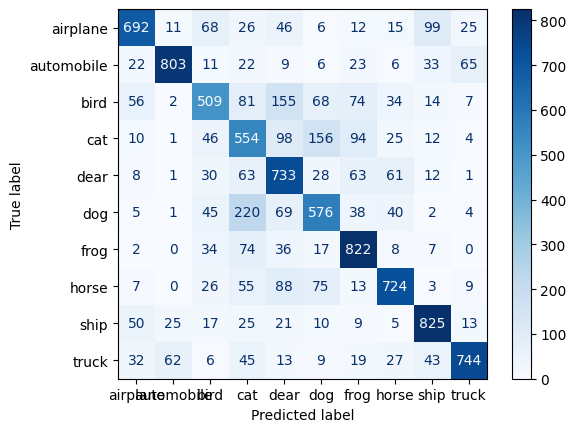

In [32]:
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
disp.plot(cmap="Blues")
plt.show()